# Simplified CANN

In [ ]:

import numpy as np
from typing import Callable
from scipy.spatial.distance import cdist
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from umap.umap_ import UMAP
from numba import jit

class EvolvedCANN(object):
    
    def __init__(self):
        # Network basic parameters
        self._nn = 1000 # Number of neurons.
        self._np = 200 # number of place fields.
        self._x_centers = np.zeros(self._nn, np.float64) * np.nan # Place field centers.
        self._L = 8.88 # Length of the track (meters).
        self._rho = self._np / self._L # Density of place fields (fields per meter).
        self._field_size_sigma = 0.2 # Standard deviation of place fields.
        self._pc_index = np.sort(np.random.choice(
            self._nn, 
            size=self._np, 
            replace=False
        )) # Place cell indices.
        self._rand_index = np.sort(np.random.choice(
            self._nn, 
            size=self._np, 
            replace=False
        )) # Cell indices for new maps.
        self._x_centers_rand = np.zeros(self._nn)
        self._x_centers_rand[self._rand_index] = np.random.uniform(0, self._L, self._np) # Place field centers for new maps.
        self._activated_cells_map2 = np.zeros(self._np)
        
        # Retrieval Sharpness
        self._rp_sharpness = 10
        
        # Noise distribution
        self._weight_noise_sigma = 0.005
        self._input_noise_sigma = 0.002

        # Weight matrix and BTSP features
        self._temporal_sigma = 2 # seconds
        self._vel_map1 = 0.2 # m/s
        self._activity_thre = 0.6 # Activity threshold for plateau initiation
        self._J0 = 0.005 # Global inhibition
        self._J1 = 0.02 # Local excitation
        self._alpha = 50 # amplification factor for weight updates
        self._W = np.zeros((self._nn, self._nn)) # Weight matrix
        self._W1 = np.zeros((self._nn, self._nn)) # Weight matrix for map 1
        self._W2 = np.zeros((self._nn, self._nn)) # Weight matrix for map 2
        self._WI1 = np.zeros((self._nn, self._nn)) # Weight matrix for path integration input
        self._WI0 = np.zeros((self._nn, self._nn)) # Initial weight matrix for path integration input
        np.fill_diagonal(self._WI0, 1)
        
        # Dynamical variables
        self._t = 0
        self._x = 0.0
        self._dt = 0.05 # seconds
        self._tau = 1.0
        self._c = 0.0 # Current correlation coefficient between PVr and PVm
        self._rp = 0.0 # Retrieval progress, [0, 1]
        self._u = np.zeros(self._nn) # Real-time population vector activity (PVr)
        self._v = np.zeros(self._nn) # PV anticipated retrieved (PVm)
        self._Iext = np.zeros(self._nn) # external input
        self._r = np.zeros(self._nn) # Tuning curve of all neurons, including non-place cells.
        self._AT = np.full(self._nn, -np.inf) # Activate Time of each neurons
        
        # Parameters that determine retrievals or not
        self._corr_thre = 0.2 # Threshold of Pearson correlation coefficient.
        self._init_map1()
    
    @property
    def nn(self):
        return self._nn
    @property
    def npc(self):
        return self._np
    @property
    def pc_index(self):
        return self._pc_index
    
    @property
    def W(self):
        return self._W
            
    def _init_map1(self):
        """Initialize the Map 1 that is pre-wired.
        """
        # Initialize the Map 1 that is pre-wired.
        x_centers = np.linspace(0, self._L, self._np+1)
        self._x_centers[self._pc_index] = (x_centers[:-1] + x_centers[1:]) / 2
        self._r: Callable[[float], np.ndarray] = self.T
        
    def _init_u(self, random_degree: float=0.8):
        """Initial activity bump shares some similarity with the tuning curve
        of map 1 at x = 0."""
        rand_idx = np.random.choice(
            self._np, 
            size=int(self._np * random_degree),
            replace=False
        )
        rand_idx2 = rand_idx[np.random.permutation(len(rand_idx))]
        self._u0 = self.T(0)
        self._u0[rand_idx] = self._u[rand_idx2]
        self._u0 = self._u0 / np.nanmax(self._u0)
        self._u0[(self._u0 < 0) | np.isnan(self._u0)] = 0
        
    def _reset_path_integration(self) -> np.ndarray:
        """When the animal is first introduced to a new starting point, the path integration is mismatched with sensory cues."""
        WI1 = np.zeros((self._nn, self._nn))
        np.fill_diagonal(WI1, 1)
        return WI1[:, np.random.permutation(self._nn)]

    def _init_W(self):
        """Initialize the weight matrix for map 1.
        """
        cdist_mat = cdist(self._x_centers[self._pc_index, None], self._x_centers[self._pc_index, None], metric='euclidean')
        #Ricker wavelet
        self._W1[np.ix_(self._pc_index, self._pc_index)] = np.exp(
            -0.5 * (cdist_mat / (self._temporal_sigma*self._vel_map1)) ** 2
        ) * self._J1
        self._W = self._W1 + self._W2 + np.random.randn(self._nn, self._nn) * self._weight_noise_sigma - self._J0
        return self._W

    def T2(self, x: float) -> np.ndarray:
        """Tuning curve of all neurons, including non-place cells, at all positions.
        
        Returns
        -------
        np.ndarray
            Tuning curve of all neurons, including non-place cells, at all positions. Shape: (self._nn, 100).
        """
        tuning_curve = np.exp(
            -0.5 * (self._x_centers_rand - x) ** 2 / self._field_size_sigma ** 2
        )
        tuning_curve[np.isnan(tuning_curve)] = 0
        return tuning_curve

    def dT2(self, x, dx=1e-3):
        """Numerical derivative of the tuning curve at all positions.
        """
        return (self.T2(x + dx) - self.T2(x - dx)) / (2 * dx)

    def T(self, x: float) -> np.ndarray:
        """Tuning curve of all neurons, including non-place cells.
        
        Parameters
        ----------
        x : float
            Animal's position on the track.
            
        Returns
        -------
        np.ndarray
            Tuning curve of all neurons, including non-place cells. Shape: (self._nn,). 
        """
        assert 0 <= x <= self._L, "x is out of bounds."
        tuning_curve = np.exp(
            -0.5 * (self._x_centers - x) ** 2 / self._field_size_sigma ** 2
        )
        tuning_curve[np.isnan(tuning_curve)] = 0
        return tuning_curve
    
    def dT(self, x, dx=1e-3):
        """Numerical derivative of the tuning curve.
        """
        return (self.T(x + dx) - self.T(x - dx)) / (2 * dx)
        
    def sigmoid(self, x: np.ndarray) -> np.ndarray:
        """Sigmoid activation function
        """
        return 1 / (1 + np.exp(-x+0.2))

    def update_corr(self, u: np.ndarray, v: np.ndarray) -> float:
        """Check if the network is retrieving the map 1.

        Parameters
        ----------
        u : np.ndarray
            Real-time population vector activity (PVr).
        v : np.ndarray
            PV anticipated retrieved (PVm).

        Returns
        -------
        bool
            True if the network is retrieving the map 1, False otherwise.
        """
        pc_index = self._pc_index
        return np.corrcoef(u[pc_index], v[pc_index])[0, 1]

    def update_rp(self, corr: float) -> float:
        """Logistic function to update the probability of dendritic plateaus,
        depending on the degree of retrievals.
        
        Parameters
        ----------
        corr : float
            Pearson correlation coefficient between PVr and PVm.

        Returns
        -------
        float
            Updated probability of dendritic plateaus.
        """
        if np.isnan(corr):
            return 0
        
        _rp = 1 / (1 + np.exp(-self._rp_sharpness * (corr - self._corr_thre)))
        return _rp

    def update_W(self):
        """Update the recurrent weight matrix with BTSP-like learning rule.
        """
        time_intervals = cdist(
            self._AT[self._rand_index, None], 
            self._AT[self._rand_index, None], 
            metric='euclidean'
        )

        self._W2[np.ix_(self._rand_index, self._rand_index)] = np.exp(
            -0.5 * (time_intervals / self._temporal_sigma) ** 2
        ) * self._J1
        self._W = self._W1 + self._W2 + np.random.randn(self._nn, self._nn) * self._weight_noise_sigma - self._J0
        return self._W

    def update_dI(self):
        """Update the weight matrix for path integration input.
        """
        return (self._rp * self.dT(self._x) + (1 - self._rp) * self.dT2(self._x)) * self._alpha

    def simulate(
        self, 
        x0: float, 
        vel: float=0.10, 
        n_steps: int=200, 
        n_trials: int=5
    ):
        """Simulate the network dynamics.

        Parameters
        ----------
        start_x : float
            Starting position of the animal.
        vel : float, optional
            Velocity of the animal, by default 0.05 m/s.
        n_steps : int, optional
            Number of time steps to simulate, by default 200.
        """
        
        self._init_W()
        self._WI1 = self._reset_path_integration()
        self._init_u()

        # Recording variables
        u_record = np.zeros((n_trials, n_steps, self._nn)) * np.nan
        v_record = np.zeros((n_trials, n_steps, self._nn)) * np.nan
        x_record = np.zeros((n_trials, n_steps)) * np.nan
        t_record = np.zeros((n_trials, n_steps)) * np.nan
        corr_record = np.zeros((n_trials, n_steps)) * np.nan
        rp_record = np.zeros((n_trials, n_steps)) * np.nan
        #Iext_record = np.zeros((n_trials, n_steps, self._nn)) * np.nan
        #W_record = np.zeros((n_trials, n_steps, self._nn, self._nn)) * np.nan

        for trial in range(n_trials):
            self._x = x0
            self._t = 0
            self._u = self._u0
            self._v = self.T(x0)
            self._c = self.update_corr(self._u, self._v)
            self._rp = self.update_rp(self._c)
            self._AT = np.full(self._nn, -np.inf)
            self._AT[self._rand_index[0]] = self._t
            dI = self.update_dI()
            
            u_record[trial, 0] = self._u
            v_record[trial, 0] = self._v
            x_record[trial, 0] = self._x
            t_record[trial, 0] = self._t
            corr_record[trial, 0] = self._c
            rp_record[trial, 0] = self._rp
            activated_new_cell = np.nan
            #Iext_record[trial, 0] = self._Iext
            #W_record[trial, 0] = self._W
            
            for s in tqdm(range(1, n_steps)):
                # Update position
                self._x += vel * self._dt
                self._t += self._dt
                activated_new_cell = np.where(
                    (self._x_centers_rand <= self._x) &
                    (self._x_centers_rand > self._x - vel * self._dt)
                )[0]
                if self._x > self._L:
                    break

                # Update path integration signals
                # Position changes update external input
                # self._Iext = WI @ self.dT(self._x)
                
                # update_u
                W = self._W
                du = (
                    -self._u 
                    + self.sigmoid(W @ (self._rp * self.T(self._x) + (1 - self._rp) * self.T2(self._x)))
                    + dI * vel
                )
                self._u += du * self._dt / self._tau
                self._u = np.clip(self._u, 0, 1)
                self._u = self._u / np.nanmax(self._u)
                self._u[np.isnan(self._u) | (self._u < 0)] = 0
                
                # update v
                self._v = self.T(self._x)
                
                # determine if the network is retrieving map 1
                self._c = self.update_corr(self._u, self._v)
                self._rp = self.update_rp(self._c)
                
                dI = self.update_dI()
                # update recurrent weights
                if activated_new_cell.shape[0] > 0:
                    self._AT[activated_new_cell[0]] = self._t
                    self._W = self.update_W()

                # Record activity
                u_record[trial, s] = self._u
                v_record[trial, s] = self._v
                x_record[trial, s] = self._x
                t_record[trial, s] = self._t
                corr_record[trial, s] = self._c
                rp_record[trial, s] = self._rp
                #Iext_record[trial, s] = self._Iext
                #W_record[trial,s] = self._W
            
        return (
            u_record, v_record, x_record, t_record, 
            corr_record, rp_record#, Iext_record, W_record
        )
        
CANN_model = EvolvedCANN()
res = CANN_model.simulate(x0=5, vel=0.05, n_steps=1000, n_trials=5)

100%|██████████| 999/999 [00:01<00:00, 690.00it/s]


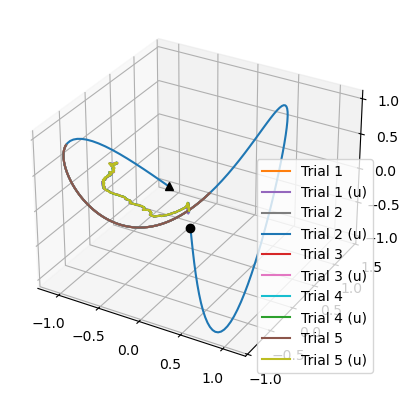

0.42815941690388165
0.4291114027619202
nan
nan
nan


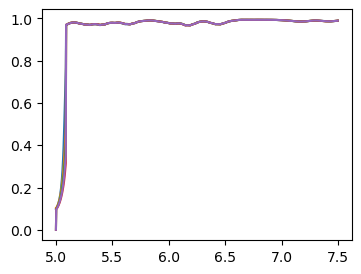

In [33]:
import matplotlib.pyplot as plt

u_record = res[0]
v_record = res[1]
x_record = res[2]
t_record = res[3]
corr_record = res[4]
rp_record = res[5]
#Iext_record = res[6]
#W_record = res[7]

spatial_maps = np.zeros((CANN_model.nn, 111))
x = np.linspace(0.04, 8.84, 111)

for i in range(111):
    spatial_maps[:, i] = CANN_model.T(x[i])

#print(np.corrcoef(u_record[0][CANN_model.pc_index], CANN_model.T(0)[CANN_model.pc_index])[0, 1])

#print(np.corrcoef(W_record[0].flatten(), W_record[-1].flatten())[0, 1])
#plt.imshow(W_record[-1], aspect='equal')
#print(np.min(W_record[0]), np.max(W_record[0]))
#plt.show()

pca = PCA(n_components=3)
spatial_maps_reduced = pca.fit_transform(spatial_maps.T)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(
    spatial_maps_reduced[:, 0], 
    spatial_maps_reduced[:, 1], 
    spatial_maps_reduced[:, 2]
)
ax.plot([spatial_maps_reduced[0, 0]], [spatial_maps_reduced[0, 1]], [spatial_maps_reduced[0, 2]], 'ko')
ax.plot([spatial_maps_reduced[-1, 0]], [spatial_maps_reduced[-1, 1]], [spatial_maps_reduced[-1, 2]], 'k^')
for n in range(5):
    idx = np.where(np.isnan(np.sum(v_record[n], axis=1))==False)[0]
    reduced_traj = pca.transform(v_record[n][idx, :])
    ax.plot(
        reduced_traj[:, 0], 
        reduced_traj[:, 1], 
        reduced_traj[:, 2],
        label=f'Trial {n+1}'
    )
    ax.plot([reduced_traj[0, 0]], [reduced_traj[0, 1]], [reduced_traj[0, 2]])
    ax.plot([reduced_traj[-1, 0]], [reduced_traj[-1, 1]], [reduced_traj[-1, 2]])

    idx = np.where(np.isnan(np.sum(u_record[n], axis=1))==False)[0]
    reduced_traj_u = pca.transform(u_record[n][idx, :])
    ax.plot(
        reduced_traj_u[:, 0], 
        reduced_traj_u[:, 1], 
        reduced_traj_u[:, 2],
        label=f'Trial {n+1} (u)'
    )
    ax.plot([reduced_traj_u[0, 0]], [reduced_traj_u[0, 1]], [reduced_traj_u[0, 2]])
    ax.plot([reduced_traj_u[-1, 0]], [reduced_traj_u[-1, 1]], [reduced_traj_u[-1, 2]])
    plt.legend()
plt.show()

fig = plt.figure(figsize=(4, 3))
ax = fig.add_subplot(111)
for trial in range(5):
    ax.plot(x_record[trial], rp_record[trial])
    print(np.corrcoef(u_record[trial, 0, :], CANN_model.T(0))[0, 1])